# Design a Machine Learning Approach to Analyse Students’ Performance Based on Their Socio-economic Status in the Kingdom of Bahrain

**MSc Artificial Intelligence — Bahrain Polytechnic**  
**Student: Jaafar Ahmed | ID: 202508989**

# Phase 6 — Model Comparison and Quality Checking

This phase performs an evidence-based quality review of the four supervised candidates forwarded from Phase 4 and integrates the three socio-economic clusters discovered in Phase 5.

## Main safeguards

- The Phase 3 holdout test set is not loaded or evaluated.
- Model quality is assessed using the saved family-aware cross-validation folds and out-of-fold predictions.
- Bootstrap confidence intervals resample families rather than isolated student records.
- Subgroup evaluation is diagnostic and must not be used to penalise, exclude, or label students.
- The phase selects finalists for explainability in Phase 7; it does not make the final holdout-tested choice.

## Phase 6 Workflow

```text
Phase 4 candidate models + out-of-fold predictions
                 +
Phase 5 socio-economic clusters
                 ↓
Cross-validated leaderboard and confidence intervals
                 ↓
Overfitting / underfitting and learning curves
                 ↓
Error analysis and robustness checks
                 ↓
Fairness and subgroup diagnostics
                 ↓
Multi-criteria finalist selection
                 ↓
Phase 7 explainability handoff
```

# Section 6.1 — Load Candidate Model Results

In [1]:
# Cell 6.1.1 — Configure Environment, Project Folders, and Analysis Settings

from pathlib import Path
from datetime import datetime
from time import perf_counter
import hashlib
import importlib.util
import json
import math
import random
import re
import shutil
import subprocess
import sys
import warnings
import zipfile

EXECUTION_ENVIRONMENT = "COLAB"  # COLAB, ANACONDA, or VSCODE

PHASE_4_MANIFEST_OVERRIDE = None
PHASE_5_MANIFEST_OVERRIDE = None

LEARNING_CURVE_FRACTIONS = [0.50, 1.00]
SEED_STABILITY_VALUES = [42, 52]
BOOTSTRAP_ITERATIONS = 300
MIN_SUBGROUP_RECORDS = 30
FINALIST_COUNT = 3
AUTO_INSTALL_MISSING_PACKAGES = True

PROJECT_TITLE = (
    "Design a Machine Learning Approach to Analyse Students’ Performance "
    "Based on Their Socio-economic Status in the Kingdom of Bahrain"
)
PROGRAMME = "MSc Artificial Intelligence — Bahrain Polytechnic"
STUDENT_NAME = "Jaafar Ahmed"
STUDENT_ID = "202508989"
RANDOM_STATE = 42
random.seed(RANDOM_STATE)

EXECUTION_ENVIRONMENT = EXECUTION_ENVIRONMENT.strip().upper()
if EXECUTION_ENVIRONMENT not in {"COLAB", "ANACONDA", "VSCODE"}:
    raise ValueError("Invalid execution environment.")

if EXECUTION_ENVIRONMENT == "COLAB":
    try:
        from google.colab import drive
        drive.mount('/content/drive')
        PROJECT_ROOT = Path('/content/drive/MyDrive/Jaafar_MSc_Thesis')
    except ImportError:
        PROJECT_ROOT = Path.cwd()
        print("Google Colab is unavailable; using:", PROJECT_ROOT)
else:
    PROJECT_ROOT = Path.cwd()

SOURCE_DATA_DIR = PROJECT_ROOT / 'data'
DATA_DIR = SOURCE_DATA_DIR
OUTPUT_ROOT = PROJECT_ROOT / 'outputs'
PHASE_4_DIR = OUTPUT_ROOT / 'Phase_04_Supervised_Learning_Algorithms'
PHASE_5_DIR = OUTPUT_ROOT / 'Phase_05_Unsupervised_Learning_Analysis'
PHASE_DIR = OUTPUT_ROOT / 'Phase_06_Model_Comparison_and_Quality_Checking'
MODEL_DIR = PHASE_DIR / 'selected_candidate_models'


def ensure_writable(folder):
    folder.mkdir(parents=True, exist_ok=True)
    test_path = folder / '.phase_06_write_test'
    test_path.write_text('test', encoding='utf-8')
    test_path.unlink()

try:
    for folder in [DATA_DIR, OUTPUT_ROOT, PHASE_DIR, MODEL_DIR]:
        ensure_writable(folder)
except (PermissionError, OSError):
    print('Standard output folders are not writable; using portable Phase 6 folders.')
    DATA_DIR = PROJECT_ROOT / 'phase_06_data'
    OUTPUT_ROOT = PROJECT_ROOT / 'phase_06_outputs'
    PHASE_DIR = OUTPUT_ROOT / 'Phase_06_Model_Comparison_and_Quality_Checking'
    MODEL_DIR = PHASE_DIR / 'selected_candidate_models'
    for folder in [DATA_DIR, OUTPUT_ROOT, PHASE_DIR, MODEL_DIR]:
        ensure_writable(folder)

RUN_TIMESTAMP = datetime.now().strftime('%Y-%m-%d_%H-%M-%S')


def safe_name(text):
    text = str(text).strip().replace('—', '-').replace('–', '-')
    text = re.sub(r'[^\w\-]+', '_', text, flags=re.UNICODE)
    return re.sub(r'_+', '_', text).strip('_') or 'Unnamed'


def create_cell_folders(section_number, section_title, cell_number, cell_title):
    base = (
        PHASE_DIR
        / safe_name(f'Section_{section_number}_{section_title}')
        / safe_name(f'Cell_{cell_number}_{cell_title}')
    )
    folders = {
        'tables': base / 'tables',
        'figures': base / 'figures',
        'reports': base / 'reports',
        'models': base / 'models',
        'files': base / 'files',
    }
    for folder in folders.values():
        folder.mkdir(parents=True, exist_ok=True)
    return folders


def save_dataframe(dataframe, folders, file_stem, index=False):
    path = folders['tables'] / f'{file_stem}.csv'
    dataframe.to_csv(path, index=index, encoding='utf-8-sig')
    return path


def save_json_report(data, folders, file_stem):
    path = folders['reports'] / f'{file_stem}.json'
    with path.open('w', encoding='utf-8') as file:
        json.dump(data, file, ensure_ascii=False, indent=2, default=str)
    return path


def sha256_file(path):
    digest = hashlib.sha256()
    with Path(path).open('rb') as file:
        for block in iter(lambda: file.read(1024 * 1024), b''):
            digest.update(block)
    return digest.hexdigest()


def load_table(path):
    path = Path(path)
    if path.suffix.lower() == '.csv':
        try:
            return pd.read_csv(path, encoding='utf-8-sig')
        except UnicodeDecodeError:
            return pd.read_csv(path, encoding='latin-1')
    if path.suffix.lower() in {'.xlsx', '.xls'}:
        return pd.read_excel(path)
    raise ValueError(f'Unsupported input format: {path.suffix}')

folders = create_cell_folders(
    '06_01', 'Load_Candidate_Model_Results',
    '06_01_01', 'Configure_Environment_Project_Folders_and_Analysis_Settings'
)
configuration = {
    'project_title': PROJECT_TITLE,
    'student_name': STUDENT_NAME,
    'student_id': STUDENT_ID,
    'execution_environment': EXECUTION_ENVIRONMENT,
    'project_root': str(PROJECT_ROOT),
    'phase_6_directory': str(PHASE_DIR),
    'learning_curve_fractions': LEARNING_CURVE_FRACTIONS,
    'seed_stability_values': SEED_STABILITY_VALUES,
    'bootstrap_iterations': BOOTSTRAP_ITERATIONS,
    'minimum_subgroup_records': MIN_SUBGROUP_RECORDS,
    'finalist_count': FINALIST_COUNT,
    'random_state': RANDOM_STATE,
    'run_timestamp': RUN_TIMESTAMP,
}
save_json_report(configuration, folders, '06_01_01_project_configuration')
print('Project root:', PROJECT_ROOT)
print('Phase 6 folder:', PHASE_DIR)

Google Colab is unavailable; using: C:\Users\User\Desktop\All
Project root: C:\Users\User\Desktop\All
Phase 6 folder: C:\Users\User\Desktop\All\outputs\Phase_06_Model_Comparison_and_Quality_Checking


In [2]:
# Cell 6.1.2 — Install Libraries and Define Visual Identity

required_packages = {
    'pandas': 'pandas', 'numpy': 'numpy', 'matplotlib': 'matplotlib',
    'scipy': 'scipy', 'sklearn': 'scikit-learn', 'joblib': 'joblib',
    'catboost': 'catboost',
}
installation_rows = []
for import_name, package_name in required_packages.items():
    installed = importlib.util.find_spec(import_name) is not None
    if installed:
        status = 'Already installed'
    elif AUTO_INSTALL_MISSING_PACKAGES:
        subprocess.check_call([sys.executable, '-m', 'pip', 'install', package_name])
        status = 'Installed during this run'
    else:
        raise ImportError(f'Missing package: {package_name}')
    installation_rows.append({
        'import_name': import_name, 'package_name': package_name, 'status': status
    })

import joblib
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.colors import LinearSegmentedColormap
import numpy as np
import pandas as pd
import scipy
import sklearn
from catboost import CatBoostClassifier
from scipy.stats import t
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.metrics import (
    accuracy_score, balanced_accuracy_score, confusion_matrix,
    f1_score, precision_recall_fscore_support, precision_score, recall_score,
)
from sklearn.pipeline import Pipeline

warnings.filterwarnings('default')
np.random.seed(RANDOM_STATE)
pd.set_option('display.max_columns', 180)
pd.set_option('display.max_rows', 180)
pd.set_option('display.width', 220)

THEME = {
    'maroon': '#6B1E32', 'deep_maroon': '#43101F', 'gold': '#D4A64A',
    'teal': '#237A7A', 'coral': '#D96850', 'indigo': '#525B92',
    'sage': '#7A9B76', 'sand': '#D9C7A3', 'warm_white': '#F7F4EF',
    'charcoal': '#2E3035', 'soft_grey': '#D8D5D0',
}
MODEL_COLORS = {
    'Dummy Baseline': '#999999',
    'Logistic Regression': THEME['maroon'],
    'K-Nearest Neighbours': THEME['gold'],
    'Support Vector Machine': THEME['indigo'],
    'Decision Tree': THEME['coral'],
    'Random Forest': THEME['teal'],
    'Gradient Boosting': THEME['sage'],
    'XGBoost': '#965D41',
    'CatBoost': '#7A4E9D',
    'Multi-Layer Perceptron': '#3F6F8F',
}
MODEL_FALLBACK_COLORS = [
    THEME['maroon'], THEME['gold'], THEME['teal'], THEME['coral'],
    THEME['indigo'], THEME['sage'], '#965D41', '#7A4E9D', '#3F6F8F',
]


def get_model_color(model_name):
    """Return a stable colour for every known or newly appearing model."""
    if model_name in MODEL_COLORS:
        return MODEL_COLORS[model_name]
    fallback_index = sum(ord(character) for character in str(model_name)) % len(
        MODEL_FALLBACK_COLORS
    )
    return MODEL_FALLBACK_COLORS[fallback_index]


CLASS_COLORS = {'Low': THEME['coral'], 'Medium': THEME['gold'], 'High': THEME['teal']}

mpl.rcParams.update({
    'figure.facecolor': THEME['warm_white'], 'axes.facecolor': THEME['warm_white'],
    'savefig.facecolor': THEME['warm_white'], 'text.color': THEME['charcoal'],
    'axes.labelcolor': THEME['charcoal'], 'xtick.color': THEME['charcoal'],
    'ytick.color': THEME['charcoal'], 'font.size': 10,
    'axes.titleweight': 'bold', 'axes.titlesize': 15, 'legend.frameon': False,
})


def style_axis(axis, title, subtitle=None, grid_axis='y'):
    axis.set_title(title, loc='left', pad=18, fontweight='bold')
    if subtitle:
        axis.text(0, 1.015, subtitle, transform=axis.transAxes,
                  fontsize=9, color='#5B5B5B', va='bottom')
    axis.spines['top'].set_visible(False)
    axis.spines['right'].set_visible(False)
    axis.spines['left'].set_alpha(0.35)
    axis.spines['bottom'].set_alpha(0.35)
    if grid_axis:
        axis.grid(axis=grid_axis, alpha=0.16)
    axis.set_axisbelow(True)


def save_figure(figure, folders, file_stem):
    path = folders['figures'] / f'{file_stem}.png'
    figure.text(0.01, 0.01,
                'MSc Artificial Intelligence — Bahrain Polytechnic | Phase 6',
                fontsize=7.5, color='#666666')
    figure.savefig(path, dpi=300, bbox_inches='tight')
    return path

folders = create_cell_folders(
    '06_01', 'Load_Candidate_Model_Results',
    '06_01_02', 'Install_Libraries_and_Define_Visual_Identity'
)
installation_report = pd.DataFrame(installation_rows)
library_versions = pd.DataFrame([
    ['Python', sys.version.split()[0]], ['pandas', pd.__version__],
    ['numpy', np.__version__], ['scipy', scipy.__version__],
    ['scikit-learn', sklearn.__version__], ['joblib', joblib.__version__],
], columns=['library', 'version'])
save_dataframe(installation_report, folders, '06_01_02_installation_report')
save_dataframe(library_versions, folders, '06_01_02_library_versions')
display(library_versions)

,library,version
0,Python,3.13.5
1,pandas,2.2.3
2,numpy,2.1.3
3,scipy,1.15.3
4,scikit-learn,1.6.1
5,joblib,1.4.2


In [3]:
# Cell 6.1.3 — Locate Phase 4 and Phase 5 Handoffs

folders = create_cell_folders(
    '06_01', 'Load_Candidate_Model_Results',
    '06_01_03', 'Locate_Phase_4_and_Phase_5_Handoffs'
)


def first_existing(candidates, description):
    for candidate in candidates:
        if candidate is None:
            continue
        path = Path(candidate).expanduser()
        if path.exists():
            return path
    raise FileNotFoundError(f'Could not locate {description}.')

phase_4_candidates = [
    PHASE_4_MANIFEST_OVERRIDE,
    PHASE_4_DIR / 'phase_04_handoff_manifest_for_phase_06.json',
    OUTPUT_ROOT / 'phase_04_handoff_manifest_for_phase_06.json',
    PROJECT_ROOT / 'phase_04_handoff_manifest_for_phase_06.json',
    Path.cwd() / 'phase_04_handoff_manifest_for_phase_06.json',
]
if PHASE_4_DIR.exists():
    phase_4_candidates += list(PHASE_4_DIR.rglob('phase_04_handoff_manifest_for_phase_06.json'))
PHASE_4_MANIFEST_PATH = first_existing(phase_4_candidates, 'Phase 4 handoff')

phase_5_candidates = [
    PHASE_5_MANIFEST_OVERRIDE,
    PHASE_5_DIR / 'phase_05_handoff_manifest_for_phase_06.json',
    OUTPUT_ROOT / 'phase_05_handoff_manifest_for_phase_06.json',
    PROJECT_ROOT / 'phase_05_handoff_manifest_for_phase_06.json',
    Path.cwd() / 'phase_05_handoff_manifest_for_phase_06.json',
]
if PHASE_5_DIR.exists():
    phase_5_candidates += list(PHASE_5_DIR.rglob('phase_05_handoff_manifest_for_phase_06.json'))
PHASE_5_MANIFEST_PATH = first_existing(phase_5_candidates, 'Phase 5 handoff')

with PHASE_4_MANIFEST_PATH.open('r', encoding='utf-8') as file:
    phase_4_manifest = json.load(file)
with PHASE_5_MANIFEST_PATH.open('r', encoding='utf-8') as file:
    phase_5_manifest = json.load(file)

artifacts = {
    'training': first_existing([
        phase_4_manifest.get('training_dataset'),
        SOURCE_DATA_DIR / 'phase_03_training_dataset_for_phase_04.csv',
        Path.cwd() / 'data' / 'phase_03_training_dataset_for_phase_04.csv',
    ], 'training dataset'),
    'cv_assignment': first_existing([
        phase_4_manifest.get('cv_assignment'),
        phase_4_manifest.get('cross_validation_assignment'),
        SOURCE_DATA_DIR / 'phase_03_cross_validation_folds.csv',
    ], 'CV assignment'),
    'leaderboard': first_existing([
        phase_4_manifest.get('leaderboard'),
        SOURCE_DATA_DIR / 'phase_04_supervised_model_leaderboard.csv',
    ], 'Phase 4 leaderboard'),
    'fold_results': first_existing([
        phase_4_manifest.get('fold_results'),
        SOURCE_DATA_DIR / 'phase_04_all_fold_results.csv',
    ], 'Phase 4 fold results'),
    'summary_results': first_existing([
        phase_4_manifest.get('summary_results'),
        SOURCE_DATA_DIR / 'phase_04_all_summary_results.csv',
    ], 'Phase 4 summary results'),
    'oof_predictions': first_existing([
        phase_4_manifest.get('oof_predictions'),
        SOURCE_DATA_DIR / 'phase_04_all_oof_predictions.csv',
    ], 'Phase 4 OOF predictions'),
    'model_registry': first_existing([
        phase_4_manifest.get('model_registry'),
        SOURCE_DATA_DIR / 'phase_04_model_registry.csv',
    ], 'Phase 4 model registry'),
    'cluster_assignments': first_existing([
        phase_5_manifest.get('cluster_assignments'),
        SOURCE_DATA_DIR / 'phase_05_cluster_assignments.csv',
    ], 'Phase 5 cluster assignments'),
}

training_data = load_table(artifacts['training'])
cv_assignment = load_table(artifacts['cv_assignment'])
phase_4_leaderboard = load_table(artifacts['leaderboard'])
phase_4_fold_results = load_table(artifacts['fold_results'])
phase_4_summaries = load_table(artifacts['summary_results'])
all_oof_predictions = load_table(artifacts['oof_predictions'])
model_registry = load_table(artifacts['model_registry'])
cluster_assignments = load_table(artifacts['cluster_assignments'])

candidate_manifest_rows = pd.DataFrame(phase_4_manifest['candidate_models'])
CANDIDATE_MODELS = candidate_manifest_rows['model'].tolist()
LEARNING_CURVE_MODELS = CANDIDATE_MODELS[:2]
SEED_STABILITY_MODELS = CANDIDATE_MODELS[:1]
TARGET_CLASSES = ['Low', 'Medium', 'High']
LABEL_TO_INTEGER = phase_4_manifest.get('target_mapping', {'Low': 0, 'Medium': 1, 'High': 2})
INTEGER_TO_LABEL = {int(value): key for key, value in LABEL_TO_INTEGER.items()}

loading_summary = pd.DataFrame([
    ['Training records', len(training_data)],
    ['Candidate models', len(CANDIDATE_MODELS)],
    ['OOF prediction rows', len(all_oof_predictions)],
    ['Phase 5 clusters', phase_5_manifest.get('selected_cluster_count')],
    ['Holdout test used', False],
])
loading_summary.columns = ['loading_measure', 'value']
save_dataframe(loading_summary, folders, '06_01_03_loading_summary')
display(candidate_manifest_rows)
print('Holdout loaded:', False)

,rank,model,stage,model_path,mean_macro_f1,std_macro_f1,mean_balanced_accuracy
0,1,Logistic Regression,Baseline,C:\Users\User\Desktop\All\outputs\Phase_04_Sup...,0.552795,0.021944,0.538339
1,2,Random Forest,Tuned,C:\Users\User\Desktop\All\outputs\Phase_04_Sup...,0.541911,0.011044,0.568098
2,3,CatBoost,Tuned,C:\Users\User\Desktop\All\outputs\Phase_04_Sup...,0.541645,0.028966,0.529519
3,4,Multi-Layer Perceptron,Tuned,C:\Users\User\Desktop\All\outputs\Phase_04_Sup...,0.540982,0.029636,0.532701


Holdout loaded: False


In [4]:
# Cell 6.1.4 — Reconstruct Candidate Models and Exact Validation Folds

folders = create_cell_folders(
    '06_01', 'Load_Candidate_Model_Results',
    '06_01_04', 'Reconstruct_Candidate_Models_and_Exact_Validation_Folds'
)

ID_COLUMN = 'student_record_id'
GROUP_COLUMN = 'family_id'
TARGET_COLUMN = 'academic_performance_class'
PREDICTOR_COLUMNS = [
    column for column in training_data.columns
    if column not in {ID_COLUMN, GROUP_COLUMN, TARGET_COLUMN}
]
X_train = training_data[PREDICTOR_COLUMNS].copy()
y_text = training_data[TARGET_COLUMN].astype(str)
y_train = y_text.map(LABEL_TO_INTEGER).astype(int)
groups_train = training_data[GROUP_COLUMN].copy()
record_ids = training_data[ID_COLUMN].astype(str)

fold_map = cv_assignment.set_index(ID_COLUMN)['validation_fold'].astype(int)
fold_numbers = record_ids.map(fold_map)
if fold_numbers.isna().any():
    raise ValueError('Some training records are missing from CV assignment.')
CV_SPLITS = []
for fold in sorted(fold_numbers.unique()):
    validation_indices = np.flatnonzero(fold_numbers.to_numpy() == fold)
    training_indices = np.flatnonzero(fold_numbers.to_numpy() != fold)
    CV_SPLITS.append((training_indices, validation_indices))

candidate_specs = {}
for item in phase_4_manifest['candidate_models']:
    path = first_existing([item['model_path']], f"model file for {item['model']}")
    loaded = joblib.load(path)
    candidate_specs[item['model']] = {
        'rank': int(item['rank']), 'stage': item['stage'], 'path': path,
        'loaded': loaded, 'type': 'catboost_bundle' if isinstance(loaded, dict) else 'sklearn_pipeline',
    }

fold_check_rows = []
for fold_number, (fit_idx, val_idx) in enumerate(CV_SPLITS, start=1):
    overlap = set(groups_train.iloc[fit_idx]).intersection(set(groups_train.iloc[val_idx]))
    fold_check_rows.append({
        'fold': fold_number, 'training_records': len(fit_idx),
        'validation_records': len(val_idx), 'family_overlap': len(overlap),
    })
fold_checks = pd.DataFrame(fold_check_rows)
if (fold_checks['family_overlap'] != 0).any():
    raise AssertionError('Family overlap detected in saved folds.')

save_dataframe(fold_checks, folders, '06_01_04_fold_checks')
save_dataframe(pd.DataFrame([
    {'model': model, 'stage': spec['stage'], 'model_type': spec['type'], 'path': str(spec['path'])}
    for model, spec in candidate_specs.items()
]), folders, '06_01_04_candidate_model_registry')
display(fold_checks)

,fold,training_records,validation_records,family_overlap
0,1,1602,404,0
1,2,1602,404,0
2,3,1593,413,0
3,4,1593,413,0
4,5,1634,372,0


In [5]:
# Cell 6.1.5 — Define Unified Candidate Fitting and Prediction Helpers

folders = create_cell_folders(
    '06_01', 'Load_Candidate_Model_Results',
    '06_01_05', 'Define_Unified_Candidate_Fitting_and_Prediction_Helpers'
)


def build_candidate(model_name, seed=RANDOM_STATE, allowed_columns=None):
    spec = candidate_specs[model_name]
    loaded = spec['loaded']

    def restricted_preprocessor(preprocessor, columns):
        if columns is None:
            return clone(preprocessor)
        transformers = []
        for name, transformer, transformer_columns in preprocessor.transformers:
            original_columns = list(transformer_columns)
            selected = [column for column in original_columns if column in columns]
            if selected:
                transformed_clone = clone(transformer)
                if hasattr(transformed_clone, 'named_steps') and 'encoder' in transformed_clone.named_steps:
                    encoder = transformed_clone.named_steps['encoder']
                    categories = getattr(encoder, 'categories', 'auto')
                    if categories != 'auto':
                        selected_positions = [original_columns.index(column) for column in selected]
                        filtered_categories = [categories[position] for position in selected_positions]
                        transformed_clone.set_params(encoder__categories=filtered_categories)
                transformers.append((name, transformed_clone, selected))
        return ColumnTransformer(
            transformers=transformers,
            remainder='drop',
            verbose_feature_names_out=True,
        )

    if spec['type'] == 'catboost_bundle':
        preprocessor = restricted_preprocessor(loaded['preprocessor'], allowed_columns)
        params = loaded['model'].get_params()
        params['random_seed'] = seed
        params['verbose'] = False
        params['allow_writing_files'] = False
        params['thread_count'] = 1
        model = CatBoostClassifier(**params)
        return {'type': 'catboost_bundle', 'preprocessor': preprocessor, 'model': model}

    pipeline = loaded
    preprocessor = restricted_preprocessor(pipeline.named_steps['preprocessing'], allowed_columns)
    model = clone(pipeline.named_steps['model'])
    params = model.get_params(deep=True)
    updates = {}
    if 'random_state' in params:
        updates['random_state'] = seed
    if updates:
        model.set_params(**updates)
    return {'type': 'sklearn_pipeline', 'pipeline': Pipeline([
        ('preprocessing', preprocessor), ('model', model)
    ])}


def fit_candidate(candidate, X_fit, y_fit):
    if candidate['type'] == 'sklearn_pipeline':
        candidate['pipeline'].fit(X_fit, y_fit)
    else:
        transformed = candidate['preprocessor'].fit_transform(X_fit)
        if hasattr(transformed, 'toarray'):
            transformed = transformed.toarray()
        candidate['model'].fit(transformed, y_fit)
    return candidate


def predict_candidate(candidate, X_values):
    if candidate['type'] == 'sklearn_pipeline':
        predictions = candidate['pipeline'].predict(X_values)
        probabilities = candidate['pipeline'].predict_proba(X_values)
    else:
        transformed = candidate['preprocessor'].transform(X_values)
        if hasattr(transformed, 'toarray'):
            transformed = transformed.toarray()
        predictions = candidate['model'].predict(transformed).reshape(-1).astype(int)
        probabilities = candidate['model'].predict_proba(transformed)
    return np.asarray(predictions, dtype=int), np.asarray(probabilities, dtype=float)


def fixed_class_metrics(y_true, y_pred):
    precision_values, recall_values, f1_values, support_values = precision_recall_fscore_support(
        y_true, y_pred, labels=[0, 1, 2], zero_division=0
    )
    result = {
        'accuracy': accuracy_score(y_true, y_pred),
        'balanced_accuracy': balanced_accuracy_score(y_true, y_pred),
        'precision_macro': precision_score(y_true, y_pred, labels=[0, 1, 2], average='macro', zero_division=0),
        'recall_macro': recall_score(y_true, y_pred, labels=[0, 1, 2], average='macro', zero_division=0),
        'f1_macro': f1_score(y_true, y_pred, labels=[0, 1, 2], average='macro', zero_division=0),
    }
    for index, class_name in enumerate(['low', 'medium', 'high']):
        result[f'precision_{class_name}'] = precision_values[index]
        result[f'recall_{class_name}'] = recall_values[index]
        result[f'f1_{class_name}'] = f1_values[index]
        result[f'support_{class_name}'] = int(support_values[index])
    return result

print('Unified candidate helpers are ready.')

Unified candidate helpers are ready.


# Section 6.2 — Final Cross-Validated Model Leaderboard

In [6]:
# Cell 6.2.1 — Create Candidate Leaderboard with Fold Confidence Intervals

folders = create_cell_folders(
    '06_02', 'Final_Cross_Validated_Model_Leaderboard',
    '06_02_01', 'Create_Candidate_Leaderboard_with_Fold_Confidence_Intervals'
)

candidate_fold_results = phase_4_fold_results.merge(
    candidate_manifest_rows[['model', 'stage']], on=['model', 'stage'], how='inner'
)
candidate_summary_results = phase_4_summaries.merge(
    candidate_manifest_rows[['model', 'stage']], on=['model', 'stage'], how='inner'
)

ci_rows = []
for (model, stage), group in candidate_fold_results.groupby(['model', 'stage']):
    mean_value = group['f1_macro'].mean()
    std_value = group['f1_macro'].std(ddof=1)
    critical = t.ppf(0.975, df=len(group)-1)
    margin = critical * std_value / math.sqrt(len(group))
    ci_rows.append({
        'model': model, 'stage': stage, 'macro_f1_mean': mean_value,
        'macro_f1_std': std_value, 'macro_f1_ci95_lower': mean_value-margin,
        'macro_f1_ci95_upper': mean_value+margin,
    })
fold_confidence_intervals = pd.DataFrame(ci_rows)

candidate_leaderboard = candidate_summary_results.merge(
    fold_confidence_intervals, on=['model', 'stage'], how='left'
).sort_values(
    ['mean_f1_macro', 'mean_balanced_accuracy', 'std_f1_macro'],
    ascending=[False, False, True]
).reset_index(drop=True)
candidate_leaderboard.insert(0, 'phase_6_initial_rank', np.arange(1, len(candidate_leaderboard)+1))

save_dataframe(candidate_fold_results, folders, '06_02_01_candidate_fold_results')
save_dataframe(candidate_leaderboard, folders, '06_02_01_candidate_leaderboard')
display(candidate_leaderboard[[
    'phase_6_initial_rank', 'model', 'stage', 'mean_f1_macro', 'std_f1_macro',
    'macro_f1_ci95_lower', 'macro_f1_ci95_upper', 'mean_balanced_accuracy',
    'mean_accuracy', 'mean_recall_low', 'mean_recall_medium', 'mean_recall_high'
]].round(4))

,phase_6_initial_rank,model,stage,mean_f1_macro,std_f1_macro,macro_f1_ci95_lower,macro_f1_ci95_upper,mean_balanced_accuracy,mean_accuracy,mean_recall_low,mean_recall_medium,mean_recall_high
0,1,Logistic Regression,Baseline,0.5528,0.0219,0.5255,0.5800,0.5383,0.5890,0.5070,0.7488,0.3592
1,2,Random Forest,Tuned,0.5419,0.0110,0.5282,0.5556,0.5681,0.5368,0.6616,0.4349,0.6077
2,3,CatBoost,Tuned,0.5416,0.0290,0.5057,0.5776,0.5295,0.5760,0.4893,0.7240,0.3753
3,4,Multi-Layer Perceptron,Tuned,0.5410,0.0296,0.5042,0.5778,0.5327,0.5749,0.5429,0.7048,0.3505


# Section 6.3 — Baseline and Tuned Model Comparison

In [7]:
# Cell 6.3.1 — Compare Baseline and Tuned Performance

folders = create_cell_folders(
    '06_03', 'Baseline_and_Tuned_Model_Comparison',
    '06_03_01', 'Compare_Baseline_and_Tuned_Performance'
)

baseline_rows = phase_4_summaries[
    (phase_4_summaries['model'].isin(CANDIDATE_MODELS)) &
    (phase_4_summaries['stage'] == 'Baseline')
].set_index('model')
tuned_rows = phase_4_summaries[
    (phase_4_summaries['model'].isin(CANDIDATE_MODELS)) &
    (phase_4_summaries['stage'] == 'Tuned')
].set_index('model')

comparison_rows = []
for model in CANDIDATE_MODELS:
    if model not in baseline_rows.index or model not in tuned_rows.index:
        continue
    comparison_rows.append({
        'model': model,
        'baseline_macro_f1': baseline_rows.loc[model, 'mean_f1_macro'],
        'tuned_macro_f1': tuned_rows.loc[model, 'mean_f1_macro'],
        'macro_f1_change': tuned_rows.loc[model, 'mean_f1_macro'] - baseline_rows.loc[model, 'mean_f1_macro'],
        'baseline_f1_std': baseline_rows.loc[model, 'std_f1_macro'],
        'tuned_f1_std': tuned_rows.loc[model, 'std_f1_macro'],
        'f1_std_change': tuned_rows.loc[model, 'std_f1_macro'] - baseline_rows.loc[model, 'std_f1_macro'],
        'baseline_gap': baseline_rows.loc[model, 'mean_generalisation_gap_f1'],
        'tuned_gap': tuned_rows.loc[model, 'mean_generalisation_gap_f1'],
        'selected_stage': candidate_manifest_rows.set_index('model').loc[model, 'stage'],
    })
baseline_tuned_comparison = pd.DataFrame(comparison_rows)
baseline_tuned_comparison['tuning_assessment'] = np.select(
    [
        baseline_tuned_comparison['macro_f1_change'] > 0.005,
        baseline_tuned_comparison['macro_f1_change'] < -0.005,
    ],
    ['Meaningful improvement', 'Performance reduction'],
    default='Minimal practical change'
)
save_dataframe(baseline_tuned_comparison, folders, '06_03_01_baseline_tuned_comparison')
display(baseline_tuned_comparison.round(4))

,model,baseline_macro_f1,tuned_macro_f1,macro_f1_change,baseline_f1_std,tuned_f1_std,f1_std_change,baseline_gap,tuned_gap,selected_stage,tuning_assessment
0,Logistic Regression,0.5528,0.5114,-0.0414,0.0219,0.0227,0.0007,0.0110,0.0165,Baseline,Performance reduction
1,Random Forest,0.5232,0.5419,0.0187,0.0250,0.0110,-0.0140,0.4738,0.1915,Tuned,Meaningful improvement
2,CatBoost,0.5328,0.5416,0.0089,0.0133,0.0290,0.0157,0.1894,0.1811,Tuned,Meaningful improvement
3,Multi-Layer Perceptron,0.5236,0.5410,0.0174,0.0328,0.0296,-0.0032,0.0446,0.0262,Tuned,Meaningful improvement


# Section 6.4 — Overfitting and Underfitting Analysis

In [8]:
# Cell 6.4.1 — Analyse Training–Validation Gaps

folders = create_cell_folders(
    '06_04', 'Overfitting_and_Underfitting_Analysis',
    '06_04_01', 'Analyse_Training_Validation_Gaps'
)

overfit_table = candidate_leaderboard[[
    'model', 'stage', 'mean_training_f1_macro', 'mean_f1_macro',
    'mean_generalisation_gap_f1', 'std_generalisation_gap_f1'
]].copy()
overfit_table['overfitting_risk'] = pd.cut(
    overfit_table['mean_generalisation_gap_f1'],
    bins=[-np.inf, 0.04, 0.10, 0.18, np.inf],
    labels=['Low', 'Moderate', 'High', 'Very high']
).astype(str)
overfit_table['underfitting_flag'] = (
    (overfit_table['mean_training_f1_macro'] < 0.60) &
    (overfit_table['mean_f1_macro'] < 0.56)
)
overfit_table['quality_interpretation'] = np.select(
    [
        overfit_table['overfitting_risk'].isin(['High', 'Very high']),
        overfit_table['underfitting_flag'],
    ],
    ['Potential overfitting', 'Potential underfitting'],
    default='Acceptable training–validation balance'
)
save_dataframe(overfit_table, folders, '06_04_01_overfitting_underfitting_analysis')
display(overfit_table.round(4))

,model,stage,mean_training_f1_macro,mean_f1_macro,mean_generalisation_gap_f1,std_generalisation_gap_f1,overfitting_risk,underfitting_flag,quality_interpretation
0,Logistic Regression,Baseline,0.5638,0.5528,0.0110,0.0258,Low,True,Potential underfitting
1,Random Forest,Tuned,0.7334,0.5419,0.1915,0.0076,Very high,False,Potential overfitting
2,CatBoost,Tuned,0.7227,0.5416,0.1811,0.0287,Very high,False,Potential overfitting
3,Multi-Layer Perceptron,Tuned,0.5671,0.5410,0.0262,0.0346,Low,True,Potential underfitting


# Section 6.5 — Learning Curves

In [9]:
# Cell 6.5.1 — Generate Family-Aware Learning Curves

folders = create_cell_folders(
    '06_05', 'Learning_Curves',
    '06_05_01', 'Generate_Family_Aware_Learning_Curves'
)


def group_subsample_indices(indices, fraction, seed):
    if fraction >= 0.999:
        return np.asarray(indices)
    rng = np.random.default_rng(seed)
    frame = pd.DataFrame({
        'index': np.asarray(indices),
        'family_id': groups_train.iloc[indices].to_numpy(),
        'target': y_train.iloc[indices].to_numpy(),
    })
    target_records = max(40, int(round(len(indices) * fraction)))
    desired = frame['target'].value_counts(normalize=True).reindex([0,1,2], fill_value=0)
    family_stats = frame.groupby('family_id').agg(
        record_count=('index','size'),
        class_0=('target', lambda values: int((values == 0).sum())),
        class_1=('target', lambda values: int((values == 1).sum())),
        class_2=('target', lambda values: int((values == 2).sum())),
    ).reset_index()
    best_families, best_score = None, np.inf
    for attempt in range(12):
        shuffled = family_stats.iloc[rng.permutation(len(family_stats))].copy()
        cumulative = shuffled['record_count'].cumsum().to_numpy()
        stop_position = int(np.searchsorted(cumulative, target_records, side='left'))
        selected = shuffled.iloc[:min(stop_position + 1, len(shuffled))]
        class_counts = selected[['class_0','class_1','class_2']].sum().to_numpy(dtype=float)
        if (class_counts == 0).any():
            continue
        distribution = pd.Series(class_counts / class_counts.sum(), index=[0,1,2])
        selected_records = int(selected['record_count'].sum())
        score = abs(selected_records-target_records)/len(indices) + np.abs(distribution-desired).sum()
        if score < best_score:
            best_score = score
            best_families = set(selected['family_id'])
    if best_families is None:
        raise RuntimeError('Unable to create a three-class family-aware subsample.')
    return frame.loc[frame['family_id'].isin(best_families), 'index'].to_numpy()

learning_rows = []
for model_name in LEARNING_CURVE_MODELS:
    for fraction in LEARNING_CURVE_FRACTIONS:
        for fold_number, (fit_indices, validation_indices) in enumerate(CV_SPLITS, start=1):
            sampled_fit = group_subsample_indices(
                fit_indices, fraction, RANDOM_STATE + fold_number + int(fraction*100)
            )
            candidate = build_candidate(model_name, seed=RANDOM_STATE)
            start = perf_counter()
            fit_candidate(candidate, X_train.iloc[sampled_fit], y_train.iloc[sampled_fit])
            fit_seconds = perf_counter() - start
            train_pred, _ = predict_candidate(candidate, X_train.iloc[sampled_fit])
            val_pred, _ = predict_candidate(candidate, X_train.iloc[validation_indices])
            learning_rows.append({
                'model': model_name, 'training_fraction': fraction, 'fold': fold_number,
                'training_records': len(sampled_fit), 'validation_records': len(validation_indices),
                'training_f1_macro': f1_score(y_train.iloc[sampled_fit], train_pred, average='macro', zero_division=0),
                'validation_f1_macro': f1_score(y_train.iloc[validation_indices], val_pred, average='macro', zero_division=0),
                'fit_time_seconds': fit_seconds,
            })
learning_curve_fold_results = pd.DataFrame(learning_rows)
learning_curve_summary = learning_curve_fold_results.groupby(
    ['model', 'training_fraction'], as_index=False
).agg(
    mean_training_records=('training_records', 'mean'),
    mean_training_f1_macro=('training_f1_macro', 'mean'),
    std_training_f1_macro=('training_f1_macro', 'std'),
    mean_validation_f1_macro=('validation_f1_macro', 'mean'),
    std_validation_f1_macro=('validation_f1_macro', 'std'),
    mean_fit_time_seconds=('fit_time_seconds', 'mean'),
)

benefit_rows=[]
for model, group in learning_curve_summary.groupby('model'):
    group = group.sort_values('training_fraction')
    final = group.iloc[-1]
    previous = group.iloc[-2]
    benefit_rows.append({
        'model': model,
        'validation_gain_75_to_100': final['mean_validation_f1_macro'] - previous['mean_validation_f1_macro'],
        'final_learning_gap': final['mean_training_f1_macro'] - final['mean_validation_f1_macro'],
        'likely_to_benefit_from_more_data': (
            final['mean_validation_f1_macro'] - previous['mean_validation_f1_macro'] > 0.005
        ),
    })
learning_curve_interpretation = pd.DataFrame(benefit_rows)
save_dataframe(learning_curve_fold_results, folders, '06_05_01_learning_curve_fold_results')
save_dataframe(learning_curve_summary, folders, '06_05_01_learning_curve_summary')
save_dataframe(learning_curve_interpretation, folders, '06_05_01_learning_curve_interpretation')
display(learning_curve_interpretation.round(4))

,model,validation_gain_75_to_100,final_learning_gap,likely_to_benefit_from_more_data
0,Logistic Regression,0.0051,0.0110,True
1,Random Forest,0.0085,0.1915,True


# Section 6.6 — Error Analysis

In [10]:
# Cell 6.6.1 — Analyse Out-of-Fold Classification Errors

folders = create_cell_folders(
    '06_06', 'Error_Analysis',
    '06_06_01', 'Analyse_Out_of_Fold_Classification_Errors'
)

candidate_oof_parts=[]
for _, candidate in candidate_manifest_rows.iterrows():
    part = all_oof_predictions[
        (all_oof_predictions['model'] == candidate['model']) &
        (all_oof_predictions['stage'] == candidate['stage'])
    ].copy()
    candidate_oof_parts.append(part)
candidate_oof = pd.concat(candidate_oof_parts, ignore_index=True)

analysis_context = training_data.merge(
    cluster_assignments[[ID_COLUMN, 'cluster_id', 'cluster_name']], on=ID_COLUMN, how='left'
)
candidate_oof = candidate_oof.merge(
    analysis_context, on=[ID_COLUMN, GROUP_COLUMN], how='left', suffixes=('', '_context')
)
candidate_oof['class_distance'] = (
    candidate_oof['true_encoded'] - candidate_oof['predicted_encoded']
).abs()
candidate_oof['error_type'] = np.select(
    [
        candidate_oof['correct_prediction'],
        candidate_oof['class_distance'] == 1,
        candidate_oof['class_distance'] == 2,
    ],
    ['Correct', 'Adjacent-class error', 'Extreme Low–High error'],
    default='Other error'
)
candidate_oof['high_confidence_error'] = (
    (~candidate_oof['correct_prediction']) &
    (candidate_oof['prediction_confidence'] >= 0.70)
)

error_summary_rows=[]
for model, group in candidate_oof.groupby('model'):
    errors = group[~group['correct_prediction']]
    error_summary_rows.append({
        'model': model,
        'records': len(group), 'errors': len(errors),
        'error_rate': len(errors)/len(group),
        'adjacent_error_rate': (group['error_type']=='Adjacent-class error').mean(),
        'extreme_error_rate': (group['error_type']=='Extreme Low–High error').mean(),
        'high_confidence_error_count': int(group['high_confidence_error'].sum()),
        'high_confidence_error_rate': group['high_confidence_error'].mean(),
        'mean_error_confidence': errors['prediction_confidence'].mean(),
    })
error_summary = pd.DataFrame(error_summary_rows)
misclassified_records = candidate_oof[~candidate_oof['correct_prediction']].copy()
confusion_summary = candidate_oof.groupby(
    ['model', 'true_class', 'predicted_class'], as_index=False
).size().rename(columns={'size':'record_count'})

save_dataframe(error_summary, folders, '06_06_01_error_summary')
save_dataframe(misclassified_records, folders, '06_06_01_misclassified_records')
save_dataframe(confusion_summary, folders, '06_06_01_confusion_summary')
display(error_summary.round(4))

,model,records,errors,error_rate,adjacent_error_rate,extreme_error_rate,high_confidence_error_count,high_confidence_error_rate,mean_error_confidence
0,CatBoost,2006,852,0.4247,0.4098,0.0150,160,0.0798,0.6084
1,Logistic Regression,2006,826,0.4118,0.4013,0.0105,47,0.0234,0.5814
2,Multi-Layer Perceptron,2006,854,0.4257,0.4093,0.0165,45,0.0224,0.5761
3,Random Forest,2006,929,0.4631,0.4272,0.0359,42,0.0209,0.5115


# Section 6.7 — Robustness Checking

In [11]:
# Cell 6.7.1 — Calculate Family-Bootstrap Confidence Intervals

folders = create_cell_folders(
    '06_07', 'Robustness_Checking',
    '06_07_01', 'Calculate_Family_Bootstrap_Confidence_Intervals'
)

bootstrap_rows=[]
rng = np.random.default_rng(RANDOM_STATE)

def macro_f1_from_confusion(matrix):
    f1_values=[]
    for class_index in range(3):
        true_positive = matrix[class_index, class_index]
        false_positive = matrix[:, class_index].sum() - true_positive
        false_negative = matrix[class_index, :].sum() - true_positive
        denominator = 2 * true_positive + false_positive + false_negative
        f1_values.append(0.0 if denominator == 0 else (2 * true_positive) / denominator)
    return float(np.mean(f1_values))

for model, group in candidate_oof.groupby('model'):
    family_matrices=[]
    for family_id, family_group in group.groupby(GROUP_COLUMN):
        family_matrices.append(confusion_matrix(
            family_group['true_encoded'].astype(int),
            family_group['predicted_encoded'].astype(int),
            labels=[0,1,2]
        ))
    family_matrices = np.stack(family_matrices)
    family_count = len(family_matrices)
    scores=[]
    for iteration in range(BOOTSTRAP_ITERATIONS):
        sampled_indices = rng.integers(0, family_count, size=family_count)
        sampled_matrix = family_matrices[sampled_indices].sum(axis=0)
        scores.append(macro_f1_from_confusion(sampled_matrix))
    bootstrap_rows.append({
        'model': model,
        'bootstrap_iterations': BOOTSTRAP_ITERATIONS,
        'bootstrap_mean_macro_f1': float(np.mean(scores)),
        'bootstrap_std_macro_f1': float(np.std(scores, ddof=1)),
        'bootstrap_ci95_lower': float(np.quantile(scores, 0.025)),
        'bootstrap_ci95_upper': float(np.quantile(scores, 0.975)),
    })
bootstrap_confidence_intervals = pd.DataFrame(bootstrap_rows)
save_dataframe(bootstrap_confidence_intervals, folders, '06_07_01_family_bootstrap_confidence_intervals')
display(bootstrap_confidence_intervals.round(4))

,model,bootstrap_iterations,bootstrap_mean_macro_f1,bootstrap_std_macro_f1,bootstrap_ci95_lower,bootstrap_ci95_upper
0,CatBoost,300,0.5408,0.0127,0.5151,0.5672
1,Logistic Regression,300,0.5524,0.0117,0.5295,0.5740
2,Multi-Layer Perceptron,300,0.5431,0.0125,0.5195,0.5682
3,Random Forest,300,0.5437,0.0113,0.5225,0.5652


In [12]:
# Cell 6.7.2 — Evaluate Random-Seed Stability

folders = create_cell_folders(
    '06_07', 'Robustness_Checking',
    '06_07_02', 'Evaluate_Random_Seed_Stability'
)

seed_rows=[]
for model_name in SEED_STABILITY_MODELS:
    for seed in SEED_STABILITY_VALUES:
        fold_scores=[]
        for fit_indices, validation_indices in CV_SPLITS:
            candidate = build_candidate(model_name, seed=seed)
            fit_candidate(candidate, X_train.iloc[fit_indices], y_train.iloc[fit_indices])
            predictions, _ = predict_candidate(candidate, X_train.iloc[validation_indices])
            fold_scores.append(f1_score(
                y_train.iloc[validation_indices], predictions,
                labels=[0,1,2], average='macro', zero_division=0
            ))
        seed_rows.append({
            'model': model_name, 'random_seed': seed,
            'mean_macro_f1': np.mean(fold_scores),
            'std_macro_f1_across_folds': np.std(fold_scores, ddof=1),
        })
seed_stability_results = pd.DataFrame(seed_rows)
seed_stability_summary = seed_stability_results.groupby('model', as_index=False).agg(
    mean_macro_f1_across_seeds=('mean_macro_f1','mean'),
    std_macro_f1_across_seeds=('mean_macro_f1','std'),
    minimum_macro_f1_across_seeds=('mean_macro_f1','min'),
    maximum_macro_f1_across_seeds=('mean_macro_f1','max'),
)
save_dataframe(seed_stability_results, folders, '06_07_02_seed_stability_results')
save_dataframe(seed_stability_summary, folders, '06_07_02_seed_stability_summary')
display(seed_stability_summary.round(4))

,model,mean_macro_f1_across_seeds,std_macro_f1_across_seeds,minimum_macro_f1_across_seeds,maximum_macro_f1_across_seeds
0,Logistic Regression,0.5528,0.0,0.5528,0.5528


In [13]:
# Cell 6.7.3 — Conduct Thematic Feature-Ablation Sensitivity Analysis

folders = create_cell_folders(
    '06_07', 'Robustness_Checking',
    '06_07_03', 'Conduct_Thematic_Feature_Ablation_Sensitivity_Analysis'
)

PRELIMINARY_TOP_MODEL = candidate_leaderboard.iloc[0]['model']
THEMATIC_FEATURE_GROUPS = {
    'Demographic and school context': ['gender','school_type','stage','overall_grade_level'],
    'Parents education': ['father_education','mother_education'],
    'Occupation and income': ['father_job','mother_job','family_income'],
    'Family structure': ['father_alive','mother_alive','marital_status','number_of_children'],
    'Support and lifestyle': ['tutoring_support','social_activities','chronic_disease','daily_smart_device_usage'],
}

ablation_rows=[]
for removed_group, removed_columns in {'No ablation': [] , **THEMATIC_FEATURE_GROUPS}.items():
    remaining_columns = [column for column in PREDICTOR_COLUMNS if column not in removed_columns]
    fold_scores=[]
    for fit_indices, validation_indices in [CV_SPLITS[index] for index in [0, 2, 4]]:
        candidate = build_candidate(
            PRELIMINARY_TOP_MODEL, seed=RANDOM_STATE, allowed_columns=remaining_columns
        )
        fit_candidate(candidate, X_train.iloc[fit_indices][remaining_columns], y_train.iloc[fit_indices])
        predictions, _ = predict_candidate(candidate, X_train.iloc[validation_indices][remaining_columns])
        fold_scores.append(f1_score(
            y_train.iloc[validation_indices], predictions,
            labels=[0,1,2], average='macro', zero_division=0
        ))
    ablation_rows.append({
        'model': PRELIMINARY_TOP_MODEL, 'removed_feature_group': removed_group,
        'remaining_feature_count': len(remaining_columns),
        'mean_macro_f1': np.mean(fold_scores), 'std_macro_f1': np.std(fold_scores, ddof=1),
    })
feature_ablation_results = pd.DataFrame(ablation_rows)
full_score = feature_ablation_results.loc[
    feature_ablation_results['removed_feature_group']=='No ablation', 'mean_macro_f1'
].iloc[0]
feature_ablation_results['macro_f1_change_from_full'] = (
    feature_ablation_results['mean_macro_f1'] - full_score
)
save_dataframe(feature_ablation_results, folders, '06_07_03_feature_ablation_results')
display(feature_ablation_results.round(4))

,model,removed_feature_group,remaining_feature_count,mean_macro_f1,std_macro_f1,macro_f1_change_from_full
0,Logistic Regression,No ablation,17,0.5619,0.0254,0.0000
1,Logistic Regression,Demographic and school context,13,0.5590,0.0217,-0.0028
2,Logistic Regression,Parents education,15,0.5284,0.0296,-0.0335
3,Logistic Regression,Occupation and income,14,0.4940,0.0244,-0.0678
4,Logistic Regression,Family structure,13,0.5557,0.0413,-0.0062
5,Logistic Regression,Support and lifestyle,13,0.5196,0.0340,-0.0423


# Section 6.8 — Fairness and Subgroup Evaluation

In [14]:
# Cell 6.8.1 — Evaluate Candidate Models across Demographic and Socio-economic Subgroups

folders = create_cell_folders(
    '06_08', 'Fairness_and_Subgroup_Evaluation',
    '06_08_01', 'Evaluate_Candidate_Models_across_Subgroups'
)

SUBGROUP_VARIABLES = [
    'gender', 'school_type', 'family_income', 'stage',
    'chronic_disease', 'cluster_name'
]
subgroup_rows=[]
for model, model_group in candidate_oof.groupby('model'):
    for variable in SUBGROUP_VARIABLES:
        for subgroup_value, subgroup in model_group.groupby(variable, dropna=False):
            if len(subgroup) < MIN_SUBGROUP_RECORDS:
                continue
            metrics = fixed_class_metrics(
                subgroup['true_encoded'].astype(int),
                subgroup['predicted_encoded'].astype(int)
            )
            subgroup_rows.append({
                'model': model, 'subgroup_variable': variable,
                'subgroup_value': str(subgroup_value), 'records': len(subgroup),
                **metrics,
            })
subgroup_performance = pd.DataFrame(subgroup_rows)

fairness_gap_rows=[]
for (model, variable), group in subgroup_performance.groupby(['model','subgroup_variable']):
    fairness_gap_rows.append({
        'model': model, 'subgroup_variable': variable,
        'eligible_subgroups': len(group),
        'accuracy_gap': group['accuracy'].max() - group['accuracy'].min(),
        'balanced_accuracy_gap': group['balanced_accuracy'].max() - group['balanced_accuracy'].min(),
        'macro_f1_gap': group['f1_macro'].max() - group['f1_macro'].min(),
        'recall_low_gap': group['recall_low'].max() - group['recall_low'].min(),
        'recall_medium_gap': group['recall_medium'].max() - group['recall_medium'].min(),
        'recall_high_gap': group['recall_high'].max() - group['recall_high'].min(),
    })
fairness_gaps = pd.DataFrame(fairness_gap_rows)
model_fairness_summary = fairness_gaps.groupby('model', as_index=False).agg(
    mean_macro_f1_gap=('macro_f1_gap','mean'),
    maximum_macro_f1_gap=('macro_f1_gap','max'),
    mean_balanced_accuracy_gap=('balanced_accuracy_gap','mean'),
    maximum_class_recall_gap=('recall_low_gap','max'),
)

save_dataframe(subgroup_performance, folders, '06_08_01_subgroup_performance')
save_dataframe(fairness_gaps, folders, '06_08_01_fairness_gaps')
save_dataframe(model_fairness_summary, folders, '06_08_01_model_fairness_summary')
display(model_fairness_summary.round(4))

,model,mean_macro_f1_gap,maximum_macro_f1_gap,mean_balanced_accuracy_gap,maximum_class_recall_gap
0,CatBoost,0.0443,0.0846,0.0365,0.9468
1,Logistic Regression,0.0266,0.0521,0.0267,0.9468
2,Multi-Layer Perceptron,0.0342,0.0707,0.0322,0.9787
3,Random Forest,0.0517,0.1402,0.0445,0.9468


# Section 6.9 — Candidate Model Selection

In [15]:
# Cell 6.9.1 — Apply Multi-Criteria Finalist Selection

folders = create_cell_folders(
    '06_09', 'Candidate_Model_Selection',
    '06_09_01', 'Apply_Multi_Criteria_Finalist_Selection'
)

selection = candidate_leaderboard.merge(
    bootstrap_confidence_intervals, on='model', how='left'
).merge(
    seed_stability_summary, on='model', how='left'
).merge(
    model_fairness_summary, on='model', how='left'
).merge(
    error_summary[['model','extreme_error_rate','high_confidence_error_rate']], on='model', how='left'
)

interpretability_scores = {
    'Logistic Regression': 1.00,
    'Random Forest': 0.75,
    'Gradient Boosting': 0.65,
    'CatBoost': 0.55,
}
selection['interpretability_score_raw'] = selection['model'].map(interpretability_scores)


def minmax_benefit(series):
    if series.max() == series.min():
        return pd.Series(1.0, index=series.index)
    return (series - series.min()) / (series.max() - series.min())


def minmax_cost(series):
    if series.max() == series.min():
        return pd.Series(1.0, index=series.index)
    return 1 - (series - series.min()) / (series.max() - series.min())

selection['score_macro_f1'] = minmax_benefit(selection['mean_f1_macro'])
selection['score_balanced_accuracy'] = minmax_benefit(selection['mean_balanced_accuracy'])
selection['score_fold_stability'] = minmax_cost(selection['std_f1_macro'])
selection['score_generalisation'] = minmax_cost(selection['mean_generalisation_gap_f1'].abs())
selection['score_fairness'] = minmax_cost(selection['mean_macro_f1_gap'])
selection['score_error_safety'] = minmax_cost(
    selection['extreme_error_rate'] + selection['high_confidence_error_rate']
)
selection['score_efficiency'] = minmax_cost(np.log1p(selection['mean_fit_time_seconds']))
selection['score_interpretability'] = selection['interpretability_score_raw']

SELECTION_WEIGHTS = {
    'score_macro_f1': 0.30,
    'score_balanced_accuracy': 0.15,
    'score_fold_stability': 0.10,
    'score_generalisation': 0.10,
    'score_fairness': 0.10,
    'score_error_safety': 0.10,
    'score_interpretability': 0.10,
    'score_efficiency': 0.05,
}
selection['overall_selection_score'] = sum(
    selection[column] * weight for column, weight in SELECTION_WEIGHTS.items()
)
selection = selection.sort_values(
    ['overall_selection_score','mean_f1_macro','mean_balanced_accuracy'],
    ascending=[False,False,False]
).reset_index(drop=True)
selection.insert(0, 'finalist_rank', np.arange(1, len(selection)+1))
selection['selected_for_phase_7'] = selection['finalist_rank'] <= FINALIST_COUNT
selection['selection_status'] = np.where(
    selection['selected_for_phase_7'], 'Phase 7 finalist', 'Reserve candidate'
)

selection_weights_table = pd.DataFrame([
    {'criterion': criterion, 'weight': weight}
    for criterion, weight in SELECTION_WEIGHTS.items()
])

save_dataframe(selection, folders, '06_09_01_multi_criteria_candidate_selection')
save_dataframe(selection_weights_table, folders, '06_09_01_selection_weights')
display(selection[[
    'finalist_rank','model','stage','overall_selection_score','mean_f1_macro',
    'mean_balanced_accuracy','std_f1_macro','mean_generalisation_gap_f1',
    'mean_macro_f1_gap','interpretability_score_raw','selected_for_phase_7'
]].round(4))

,finalist_rank,model,stage,overall_selection_score,mean_f1_macro,mean_balanced_accuracy,std_f1_macro,mean_generalisation_gap_f1,mean_macro_f1_gap,interpretability_score_raw,selected_for_phase_7
0,1,Logistic Regression,Baseline,0.8257,0.5528,0.5383,0.0219,0.0110,0.0266,1.00,True
1,2,Random Forest,Tuned,0.4417,0.5419,0.5681,0.0110,0.1915,0.0517,0.75,True
2,3,CatBoost,Tuned,0.1558,0.5416,0.5295,0.0290,0.1811,0.0443,0.55,True
3,4,Multi-Layer Perceptron,Tuned,NaN,0.5410,0.5327,0.0296,0.0262,0.0342,NaN,False


# Section 6.10 — Multiple Visualization: Model Quality

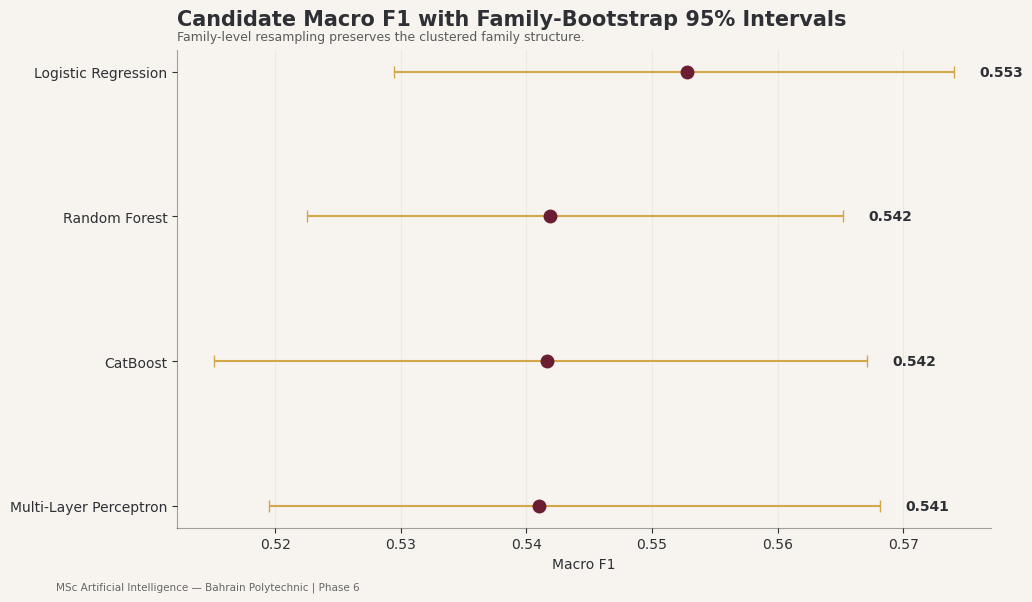

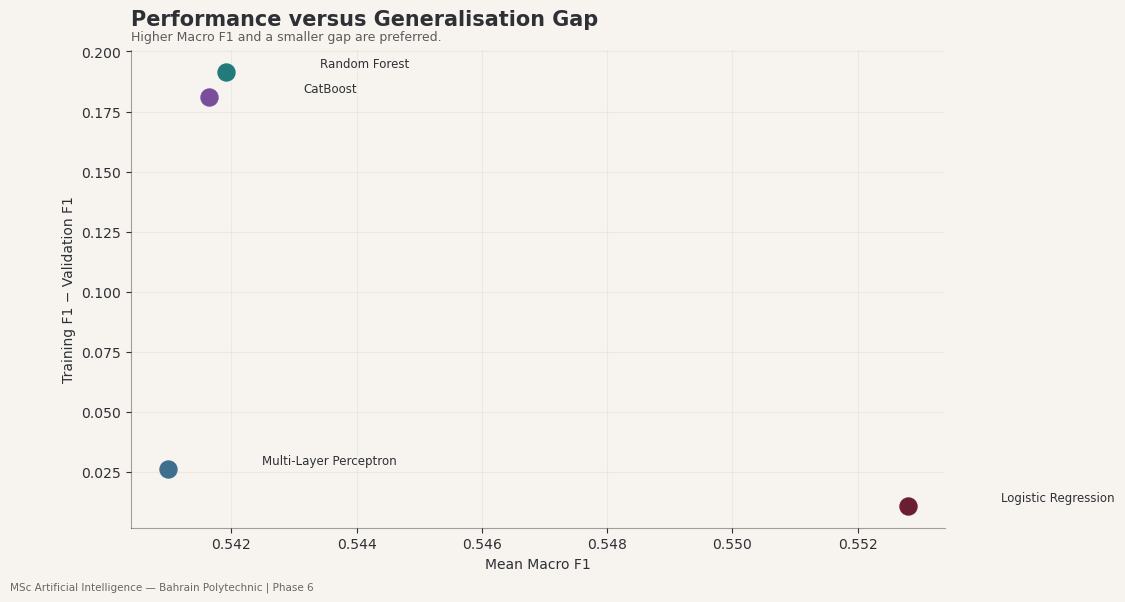

In [16]:
# Cell 6.10.1 — Visualise Candidate Performance, Confidence Intervals, and Generalisation

folders = create_cell_folders(
    '06_10', 'Multiple_Visualization_Model_Quality',
    '06_10_01', 'Visualise_Candidate_Performance_Confidence_Intervals_and_Generalisation'
)

plot_data = selection.sort_values('mean_f1_macro')
figure, axis = plt.subplots(figsize=(10.5, 6.2))
axis.errorbar(
    plot_data['mean_f1_macro'], plot_data['model'],
    xerr=[
        plot_data['mean_f1_macro'] - plot_data['bootstrap_ci95_lower'],
        plot_data['bootstrap_ci95_upper'] - plot_data['mean_f1_macro'],
    ],
    fmt='o', capsize=4, markersize=9,
    color=THEME['maroon'], ecolor=THEME['gold']
)
for _, row in plot_data.iterrows():
    axis.text(row['bootstrap_ci95_upper'] + 0.002, row['model'],
              f"{row['mean_f1_macro']:.3f}", va='center', fontweight='bold')
style_axis(axis, 'Candidate Macro F1 with Family-Bootstrap 95% Intervals',
           'Family-level resampling preserves the clustered family structure.', 'x')
axis.set_xlabel('Macro F1')
save_figure(figure, folders, '06_10_01_bootstrap_macro_f1_intervals')
plt.show()

figure, axis = plt.subplots(figsize=(10.5, 6.2))
for _, row in selection.iterrows():
    axis.scatter(
        row['mean_f1_macro'], row['mean_generalisation_gap_f1'],
        s=150, color=get_model_color(row['model'])
    )
    axis.text(row['mean_f1_macro']+0.0015, row['mean_generalisation_gap_f1']+0.002,
              row['model'], fontsize=8.5)
style_axis(axis, 'Performance versus Generalisation Gap',
           'Higher Macro F1 and a smaller gap are preferred.', 'both')
axis.set_xlabel('Mean Macro F1')
axis.set_ylabel('Training F1 − Validation F1')
save_figure(figure, folders, '06_10_01_performance_generalisation_map')
plt.show()

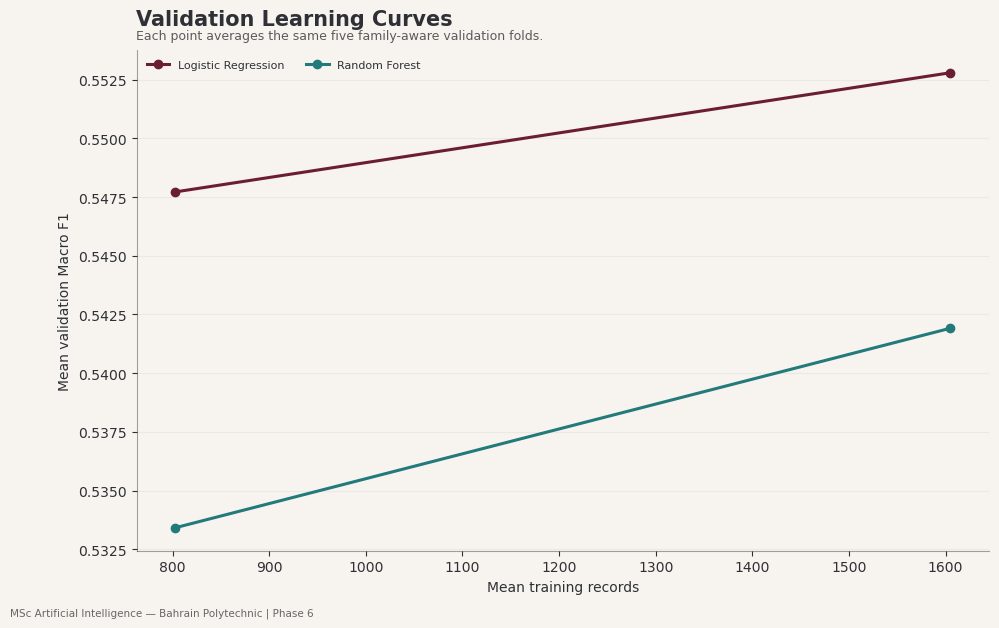

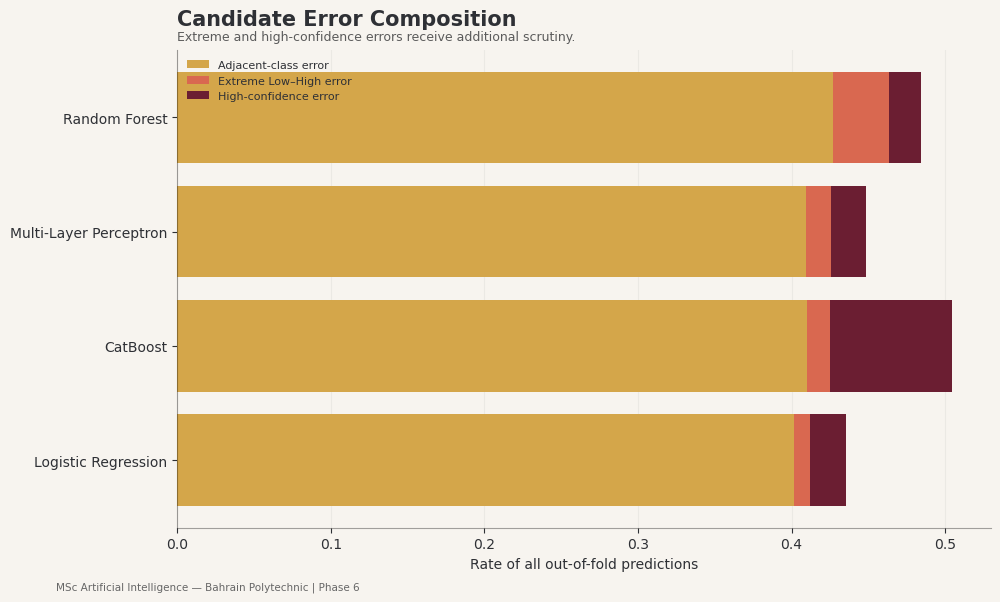

In [17]:
# Cell 6.10.2 — Visualise Learning Curves and Error Composition

folders = create_cell_folders(
    '06_10', 'Multiple_Visualization_Model_Quality',
    '06_10_02', 'Visualise_Learning_Curves_and_Error_Composition'
)

figure, axis = plt.subplots(figsize=(11, 6.5))
for model, group in learning_curve_summary.groupby('model'):
    group = group.sort_values('training_fraction')
    axis.plot(
        group['mean_training_records'], group['mean_validation_f1_macro'],
        marker='o', linewidth=2.2, color=get_model_color(model), label=model
    )
style_axis(axis, 'Validation Learning Curves',
           'Each point averages the same five family-aware validation folds.')
axis.set_xlabel('Mean training records')
axis.set_ylabel('Mean validation Macro F1')
axis.legend(ncol=2, fontsize=8)
save_figure(figure, folders, '06_10_02_validation_learning_curves')
plt.show()

error_plot = error_summary.set_index('model')[[
    'adjacent_error_rate','extreme_error_rate','high_confidence_error_rate'
]].sort_values('extreme_error_rate')
figure, axis = plt.subplots(figsize=(10.5, 6.2))
bottom = np.zeros(len(error_plot))
colors = [THEME['gold'], THEME['coral'], THEME['maroon']]
labels = ['Adjacent-class error','Extreme Low–High error','High-confidence error']
for column, label, color in zip(error_plot.columns, labels, colors):
    values = error_plot[column].to_numpy()
    axis.barh(error_plot.index, values, left=bottom, label=label, color=color)
    bottom += values
style_axis(axis, 'Candidate Error Composition',
           'Extreme and high-confidence errors receive additional scrutiny.', 'x')
axis.set_xlabel('Rate of all out-of-fold predictions')
axis.legend(fontsize=8)
save_figure(figure, folders, '06_10_02_error_composition')
plt.show()

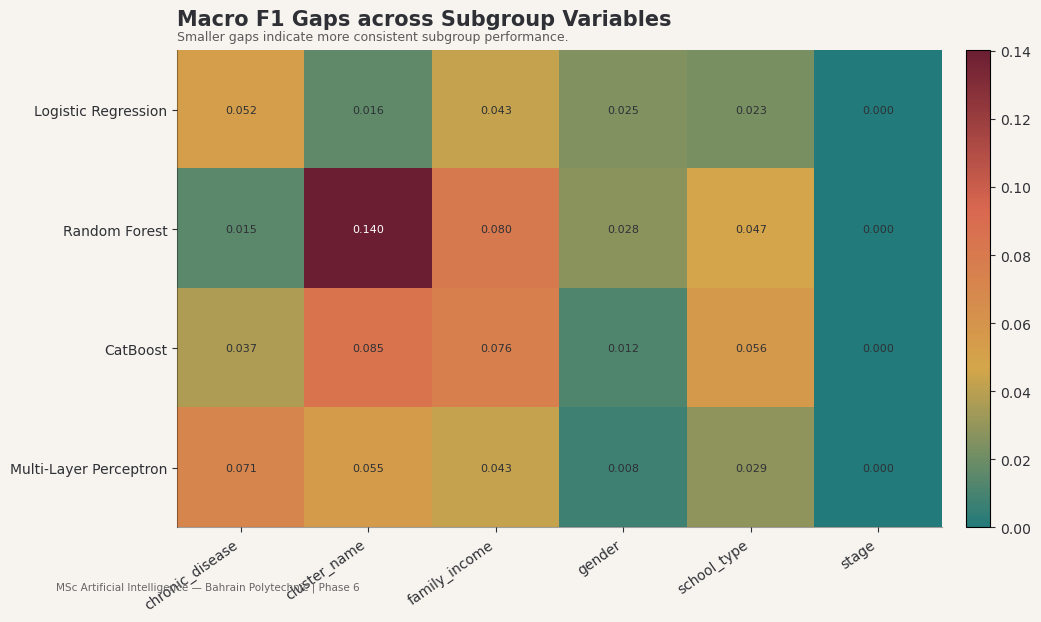

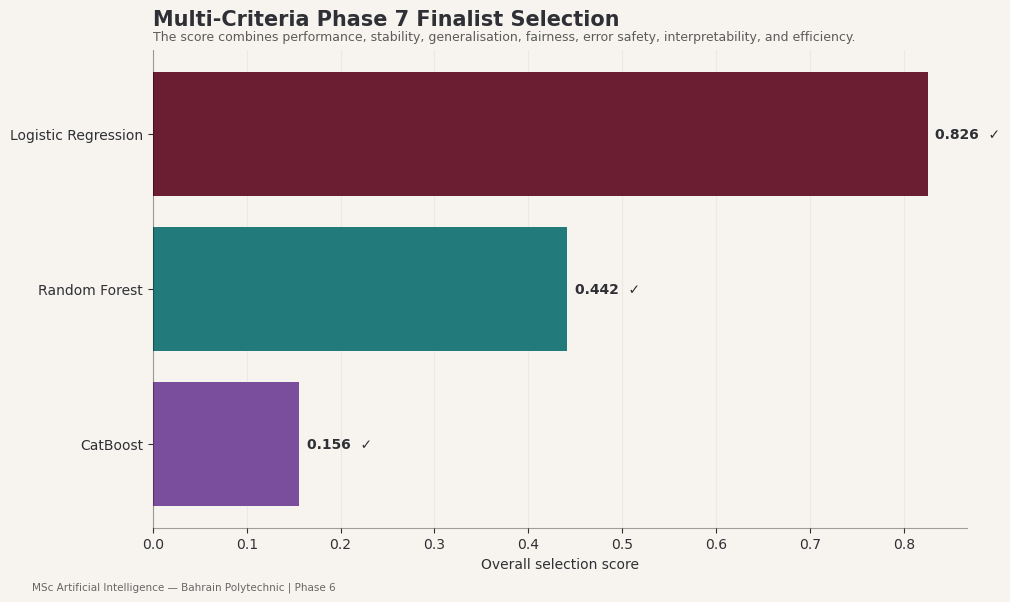

In [18]:
# Cell 6.10.3 — Visualise Fairness Gaps and Finalist Selection

folders = create_cell_folders(
    '06_10', 'Multiple_Visualization_Model_Quality',
    '06_10_03', 'Visualise_Fairness_Gaps_and_Finalist_Selection'
)

fairness_heatmap = fairness_gaps.pivot(
    index='model', columns='subgroup_variable', values='macro_f1_gap'
).reindex(selection['model'])
values = fairness_heatmap.to_numpy()
figure, axis = plt.subplots(figsize=(10.5, 6.2))
image = axis.imshow(
    values, aspect='auto', vmin=0, vmax=max(0.01, np.nanmax(values)),
    cmap=LinearSegmentedColormap.from_list(
        'fairness', [THEME['teal'], THEME['gold'], THEME['coral'], THEME['maroon']]
    )
)
axis.set_xticks(np.arange(len(fairness_heatmap.columns)))
axis.set_xticklabels(fairness_heatmap.columns, rotation=35, ha='right')
axis.set_yticks(np.arange(len(fairness_heatmap.index)))
axis.set_yticklabels(fairness_heatmap.index)
for i in range(values.shape[0]):
    for j in range(values.shape[1]):
        if np.isfinite(values[i,j]):
            axis.text(j, i, f'{values[i,j]:.3f}', ha='center', va='center', fontsize=8,
                      color='white' if values[i,j] > np.nanmax(values)*0.65 else THEME['charcoal'])
style_axis(axis, 'Macro F1 Gaps across Subgroup Variables',
           'Smaller gaps indicate more consistent subgroup performance.', None)
figure.colorbar(image, ax=axis, fraction=0.03, pad=0.03)
save_figure(figure, folders, '06_10_03_fairness_gap_heatmap')
plt.show()

final_plot = selection.sort_values('overall_selection_score')
figure, axis = plt.subplots(figsize=(10.5, 6.2))
bars = axis.barh(
    final_plot['model'], final_plot['overall_selection_score'],
    color=[get_model_color(model) for model in final_plot['model']]
)
for bar, value, selected_flag in zip(
    bars, final_plot['overall_selection_score'], final_plot['selected_for_phase_7']
):
    axis.text(bar.get_width()+0.008, bar.get_y()+bar.get_height()/2,
              f"{value:.3f}{'  ✓' if selected_flag else ''}", va='center', fontweight='bold')
style_axis(axis, 'Multi-Criteria Phase 7 Finalist Selection',
           'The score combines performance, stability, generalisation, fairness, error safety, interpretability, and efficiency.', 'x')
axis.set_xlabel('Overall selection score')
save_figure(figure, folders, '06_10_03_finalist_selection_score')
plt.show()

In [19]:
# Cell 6.10.4 — Create the Phase 6 Visualisation Catalogue

folders = create_cell_folders(
    '06_10', 'Multiple_Visualization_Model_Quality',
    '06_10_04', 'Create_the_Phase_6_Visualisation_Catalogue'
)
figure_files = sorted(PHASE_DIR.rglob('*.png'))
visualisation_catalogue = pd.DataFrame([
    {
        'figure_number': number, 'figure_name': path.stem,
        'relative_path': str(path.relative_to(PHASE_DIR)),
        'file_size_kb': round(path.stat().st_size/1024, 2),
    }
    for number, path in enumerate(figure_files, start=1)
])
save_dataframe(visualisation_catalogue, folders, '06_10_04_visualisation_catalogue')
display(visualisation_catalogue)

,figure_number,figure_name,relative_path,file_size_kb
0,1,06_10_01_bootstrap_macro_f1_intervals,Section_06_10_Multiple_Visualization_Model_Qua...,153.38
1,2,06_10_01_performance_generalisation_map,Section_06_10_Multiple_Visualization_Model_Qua...,170.38
2,3,06_10_02_error_composition,Section_06_10_Multiple_Visualization_Model_Qua...,146.25
3,4,06_10_02_validation_learning_curves,Section_06_10_Multiple_Visualization_Model_Qua...,199.09
4,5,06_10_03_fairness_gap_heatmap,Section_06_10_Multiple_Visualization_Model_Qua...,287.66
5,6,06_10_03_finalist_selection_score,Section_06_10_Multiple_Visualization_Model_Qua...,144.66


# Section 6.11 — Export Multiple Files and Phase Handoff

In [20]:
# Cell 6.11.1 — Export Official Phase 6 Results and Selected Models

folders = create_cell_folders(
    '06_11', 'Export_Multiple_Files_and_Phase_Handoff',
    '06_11_01', 'Export_Official_Phase_6_Results_and_Selected_Models'
)

OFFICIAL_PATHS = {
    'candidate_leaderboard': DATA_DIR / 'phase_06_candidate_model_leaderboard.csv',
    'candidate_selection': DATA_DIR / 'phase_06_multi_criteria_candidate_selection.csv',
    'learning_curves': DATA_DIR / 'phase_06_learning_curve_summary.csv',
    'error_summary': DATA_DIR / 'phase_06_error_analysis_summary.csv',
    'bootstrap_intervals': DATA_DIR / 'phase_06_bootstrap_confidence_intervals.csv',
    'seed_stability': DATA_DIR / 'phase_06_seed_stability_summary.csv',
    'feature_ablation': DATA_DIR / 'phase_06_feature_ablation_results.csv',
    'subgroup_performance': DATA_DIR / 'phase_06_subgroup_performance.csv',
    'fairness_gaps': DATA_DIR / 'phase_06_fairness_gaps.csv',
    'misclassified_records': DATA_DIR / 'phase_06_misclassified_records.csv',
}
TABLES_TO_EXPORT = {
    'candidate_leaderboard': candidate_leaderboard,
    'candidate_selection': selection,
    'learning_curves': learning_curve_summary,
    'error_summary': error_summary,
    'bootstrap_intervals': bootstrap_confidence_intervals,
    'seed_stability': seed_stability_summary,
    'feature_ablation': feature_ablation_results,
    'subgroup_performance': subgroup_performance,
    'fairness_gaps': fairness_gaps,
    'misclassified_records': misclassified_records,
}
for key, path in OFFICIAL_PATHS.items():
    TABLES_TO_EXPORT[key].to_csv(path, index=False, encoding='utf-8-sig')
    shutil.copy2(path, folders['files'] / path.name)

selected_model_rows=[]
for _, finalist in selection[selection['selected_for_phase_7']].iterrows():
    source = candidate_specs[finalist['model']]['path']
    destination = MODEL_DIR / source.name
    shutil.copy2(source, destination)
    selected_model_rows.append({
        'finalist_rank': int(finalist['finalist_rank']),
        'model': finalist['model'], 'stage': finalist['stage'],
        'source_model_path': str(source), 'phase_6_model_copy': str(destination),
        'sha256': sha256_file(destination),
    })
selected_model_registry = pd.DataFrame(selected_model_rows)
save_dataframe(selected_model_registry, folders, '06_11_01_selected_model_registry')

export_summary = pd.DataFrame([
    {'artifact': key, 'path': str(path), 'file_size_kb': round(path.stat().st_size/1024,2), 'sha256': sha256_file(path)}
    for key, path in OFFICIAL_PATHS.items()
])
save_dataframe(export_summary, folders, '06_11_01_export_summary')
display(selected_model_registry)

,finalist_rank,model,stage,source_model_path,phase_6_model_copy,sha256
0,1,Logistic Regression,Baseline,C:\Users\User\Desktop\All\outputs\Phase_04_Sup...,C:\Users\User\Desktop\All\outputs\Phase_06_Mod...,480c13b89d14fa657764aed7e6b45dca9e1d740fabb557...
1,2,Random Forest,Tuned,C:\Users\User\Desktop\All\outputs\Phase_04_Sup...,C:\Users\User\Desktop\All\outputs\Phase_06_Mod...,c9097b78e4c8f38ba64af2cfbe3fd156b6f78ce1f53314...
2,3,CatBoost,Tuned,C:\Users\User\Desktop\All\outputs\Phase_04_Sup...,C:\Users\User\Desktop\All\outputs\Phase_06_Mod...,02beb2bacb80361a3475472f0111df8f09960f5a5b297c...


In [21]:
# Cell 6.11.2 — Create Consolidated CSV Report Directory

folders = create_cell_folders(
    '06_11', 'Export_Multiple_Files_and_Phase_Handoff',
    '06_11_02', 'Create_Consolidated_CSV_Report_Directory'
)
REPORT_DIR = folders['files'] / 'phase_06_consolidated_reports'
REPORT_DIR.mkdir(parents=True, exist_ok=True)
REPORT_TABLES = {
    'project_configuration': pd.DataFrame([configuration]),
    'library_versions': library_versions,
    'candidate_leaderboard': candidate_leaderboard,
    'baseline_tuned_comparison': baseline_tuned_comparison,
    'overfitting_underfitting': overfit_table,
    'learning_curve_summary': learning_curve_summary,
    'learning_curve_interpretation': learning_curve_interpretation,
    'error_summary': error_summary,
    'bootstrap_confidence_intervals': bootstrap_confidence_intervals,
    'seed_stability_summary': seed_stability_summary,
    'feature_ablation_results': feature_ablation_results,
    'subgroup_performance': subgroup_performance,
    'fairness_gaps': fairness_gaps,
    'model_fairness_summary': model_fairness_summary,
    'candidate_selection': selection,
    'selection_weights': selection_weights_table,
    'selected_model_registry': selected_model_registry,
    'visualisation_catalogue': visualisation_catalogue,
    'export_summary': export_summary,
}
for name, dataframe in REPORT_TABLES.items():
    dataframe.to_csv(REPORT_DIR / f'{name}.csv', index=False, encoding='utf-8-sig')
print('Consolidated report directory:', REPORT_DIR)

Consolidated report directory: C:\Users\User\Desktop\All\outputs\Phase_06_Model_Comparison_and_Quality_Checking\Section_06_11_Export_Multiple_Files_and_Phase_Handoff\Cell_06_11_02_Create_Consolidated_CSV_Report_Directory\files\phase_06_consolidated_reports


In [22]:
# Cell 6.11.3 — Create Phase 7 Handoff Manifest and Final Quality Checks

folders = create_cell_folders(
    '06_11', 'Export_Multiple_Files_and_Phase_Handoff',
    '06_11_03', 'Create_Phase_7_Handoff_Manifest_and_Final_Quality_Checks'
)

quality_checks = pd.DataFrame([
    ['Four candidate models evaluated', len(selection) == 4, len(selection)],
    ['Every candidate has 2,000 OOF predictions', all(
        len(candidate_oof[candidate_oof['model']==model]) == len(training_data)
        for model in CANDIDATE_MODELS
    ), len(training_data)],
    ['Family bootstrap intervals completed', len(bootstrap_confidence_intervals)==4, BOOTSTRAP_ITERATIONS],
    ['Seed stability completed for the preliminary top model', len(seed_stability_summary)==len(SEED_STABILITY_MODELS), SEED_STABILITY_VALUES],
    ['Learning curves completed for the top two preliminary models', len(learning_curve_summary)==len(LEARNING_CURVE_MODELS)*len(LEARNING_CURVE_FRACTIONS), LEARNING_CURVE_FRACTIONS],
    ['Subgroup diagnostics completed', not subgroup_performance.empty, len(subgroup_performance)],
    ['Phase 7 finalists selected', int(selection['selected_for_phase_7'].sum())==FINALIST_COUNT, FINALIST_COUNT],
    ['Holdout test not used', True, False],
], columns=['quality_check','passed','details'])
save_dataframe(quality_checks, folders, '06_11_03_phase_6_quality_checks')
if not quality_checks['passed'].all():
    failed = quality_checks.loc[~quality_checks['passed'],'quality_check'].tolist()
    raise AssertionError('Phase 6 quality checks failed: ' + '; '.join(failed))

phase_7_finalists=[]
for _, row in selection[selection['selected_for_phase_7']].iterrows():
    model_record = selected_model_registry[selected_model_registry['model']==row['model']].iloc[0]
    phase_7_finalists.append({
        'finalist_rank': int(row['finalist_rank']), 'model': row['model'],
        'stage': row['stage'], 'model_path': model_record['phase_6_model_copy'],
        'overall_selection_score': float(row['overall_selection_score']),
        'mean_macro_f1': float(row['mean_f1_macro']),
        'mean_balanced_accuracy': float(row['mean_balanced_accuracy']),
        'mean_fairness_gap': float(row['mean_macro_f1_gap']),
    })

phase_7_manifest = {
    'completed_phase': 'Phase 6 — Model Comparison and Quality Checking',
    'next_phase': 'Phase 7 — Model Explainability and Interpretation',
    'training_dataset': str(artifacts['training']),
    'cv_assignment': str(artifacts['cv_assignment']),
    'candidate_selection': str(OFFICIAL_PATHS['candidate_selection']),
    'candidate_leaderboard': str(OFFICIAL_PATHS['candidate_leaderboard']),
    'learning_curves': str(OFFICIAL_PATHS['learning_curves']),
    'error_analysis': str(OFFICIAL_PATHS['error_summary']),
    'misclassified_records': str(OFFICIAL_PATHS['misclassified_records']),
    'fairness_gaps': str(OFFICIAL_PATHS['fairness_gaps']),
    'subgroup_performance': str(OFFICIAL_PATHS['subgroup_performance']),
    'feature_ablation': str(OFFICIAL_PATHS['feature_ablation']),
    'phase_5_cluster_assignments': str(artifacts['cluster_assignments']),
    'finalist_models': phase_7_finalists,
    'selection_weights': SELECTION_WEIGHTS,
    'target_mapping': LABEL_TO_INTEGER,
    'holdout_test_used': False,
    'final_holdout_evaluation_phase': 8,
    'generated_at': datetime.now().isoformat(),
}
PHASE_7_HANDOFF_PATH = save_json_report(
    phase_7_manifest, folders, 'phase_06_handoff_manifest_for_phase_07'
)
with (PHASE_DIR / 'phase_06_handoff_manifest_for_phase_07.json').open('w', encoding='utf-8') as file:
    json.dump(phase_7_manifest, file, ensure_ascii=False, indent=2)

display(quality_checks)
print('Phase 7 handoff:', PHASE_7_HANDOFF_PATH)

,quality_check,passed,details
0,Four candidate models evaluated,True,4
1,"Every candidate has 2,000 OOF predictions",True,2006
2,Family bootstrap intervals completed,True,300
3,Seed stability completed for the preliminary t...,True,"[42, 52]"
4,Learning curves completed for the top two prel...,True,"[0.5, 1.0]"
5,Subgroup diagnostics completed,True,56
6,Phase 7 finalists selected,True,3
7,Holdout test not used,True,False


Phase 7 handoff: C:\Users\User\Desktop\All\outputs\Phase_06_Model_Comparison_and_Quality_Checking\Section_06_11_Export_Multiple_Files_and_Phase_Handoff\Cell_06_11_03_Create_Phase_7_Handoff_Manifest_and_Final_Quality_Checks\reports\phase_06_handoff_manifest_for_phase_07.json


In [23]:
# Cell 6.11.4 — Create Completion Summary and ZIP Archive

folders = create_cell_folders(
    '06_11', 'Export_Multiple_Files_and_Phase_Handoff',
    '06_11_04', 'Create_Completion_Summary_and_ZIP_Archive'
)

summary_text = f"""
PHASE 6 COMPLETION SUMMARY
{'='*76}

Candidate models reviewed: {len(selection)}
Training records: {len(training_data):,}
Family-aware validation folds: {len(CV_SPLITS)}
Family bootstrap iterations: {BOOTSTRAP_ITERATIONS}
Random seeds tested: {SEED_STABILITY_VALUES}
Holdout test used: False

Phase 7 finalists:
{chr(10).join(
    f"- Rank {int(row['finalist_rank'])}: {row['model']} "
    f"(selection score {row['overall_selection_score']:.4f}, "
    f"Macro F1 {row['mean_f1_macro']:.4f})"
    for _, row in selection[selection['selected_for_phase_7']].iterrows()
)}

Important:
The selection score is a transparent decision framework, not a replacement for
final predictive metrics. The untouched holdout test remains reserved for Phase 8.
""".strip()
summary_path = folders['reports'] / '06_11_04_phase_6_summary.txt'
summary_path.write_text(summary_text, encoding='utf-8')

ZIP_PATH = folders['files'] / '06_11_04_phase_6_complete_export.zip'
with zipfile.ZipFile(ZIP_PATH, 'w', zipfile.ZIP_DEFLATED) as zip_file:
    for path in sorted(PHASE_DIR.rglob('*')):
        if path.is_file() and path != ZIP_PATH:
            zip_file.write(path, path.relative_to(PHASE_DIR))
print(summary_text)
print('ZIP:', ZIP_PATH)

PHASE 6 COMPLETION SUMMARY

Candidate models reviewed: 4
Training records: 2,006
Family-aware validation folds: 5
Family bootstrap iterations: 300
Random seeds tested: [42, 52]
Holdout test used: False

Phase 7 finalists:
- Rank 1: Logistic Regression (selection score 0.8257, Macro F1 0.5528)
- Rank 2: Random Forest (selection score 0.4417, Macro F1 0.5419)
- Rank 3: CatBoost (selection score 0.1558, Macro F1 0.5416)

Important:
The selection score is a transparent decision framework, not a replacement for
final predictive metrics. The untouched holdout test remains reserved for Phase 8.
ZIP: C:\Users\User\Desktop\All\outputs\Phase_06_Model_Comparison_and_Quality_Checking\Section_06_11_Export_Multiple_Files_and_Phase_Handoff\Cell_06_11_04_Create_Completion_Summary_and_ZIP_Archive\files\06_11_04_phase_6_complete_export.zip


# Phase 6 Completed

Phase 6 has selected the strongest and most defensible candidates for explainability in Phase 7 using performance, stability, generalisation, fairness, error safety, interpretability, and efficiency.

The untouched holdout test remains reserved for Phase 8.